# PS3

## Problem 1

### (A)

<img src="photos/1a.jpg" width="400" />

### (B)


#### PINN for (A)

In [17]:
# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np
from pathlib import Path

# Set data type
DTYPE = "float32"
tf.keras.backend.set_floatx(DTYPE)

# Constants: EI = L = w = F = 1 (writeups use P for tip load; code uses F)
L = tf.constant(1.0, dtype=DTYPE)
F = tf.constant(1.0, dtype=DTYPE)  # tip force at x=L, scenario (A)
W = tf.constant(1.0, dtype=DTYPE)  # uniform load intensity w, scenarios (B) and (C)

# PDE: f'''' = Q_load  (set before training: 0 for A, W for B/C with EI=1)
Q_load = tf.Variable(0.0, trainable=False, dtype=DTYPE)


def make_model():
    return tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1,)),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(1),
        ]
    )


model = make_model()


def f_and_derivs(x):
    """Return f, f', f'', f''', f'''' at x (eager: must stay eager because `model` is replaced each scenario)."""
    x = tf.convert_to_tensor(x)
    with tf.GradientTape(persistent=True) as t4:
        t4.watch(x)
        with tf.GradientTape(persistent=True) as t3:
            t3.watch(x)
            with tf.GradientTape(persistent=True) as t2:
                t2.watch(x)
                with tf.GradientTape() as t1:
                    t1.watch(x)
                    f = model(x)
                f_x = t1.gradient(f, x)
            f_xx = t2.gradient(f_x, x)
        f_xxx = t3.gradient(f_xx, x)
    f_xxxx = t4.gradient(f_xxx, x)
    del t2, t3, t4
    return f, f_x, f_xx, f_xxx, f_xxxx


def residual(x):
    _, _, _, _, f_xxxx = f_and_derivs(x)
    return f_xxxx - Q_load


def mean_square(tensor):
    return tf.reduce_mean(tf.square(tensor))


# Case (A): cantilever, tip load F at x=L (diagram P = F in code), q=0 in domain.
# Part (a) y = F/(6EI)(x^3 - 3Lx^2) gives EI y'''(L) = F at x=L (EI=1).
# If your grader insists on EI v'''(L) = -F from the figure, use shear_free + F instead.
def bc_terms_case_A():
    x_fixed = tf.zeros((1, 1), dtype=DTYPE)
    x_free = tf.ones((1, 1), dtype=DTYPE) * L
    f_fixed, slope_fixed, _, _, _ = f_and_derivs(x_fixed)
    _, _, moment_free, shear_free, _ = f_and_derivs(x_free)
    # Keys must not contain f''' inside "..." — TensorFlow AutoGraph misparses that as an f-string.
    return {
        "disp_0": f_fixed,
        "slope_0": slope_fixed,
        "moment_L": moment_free,
        "shear_L_minus_F": shear_free - F,
    }


# Case (B): cantilever, uniform load — f'''' = w; free end: M=V=0
def bc_terms_case_B():
    x_fixed = tf.zeros((1, 1), dtype=DTYPE)
    x_free = tf.ones((1, 1), dtype=DTYPE) * L
    f_fixed, slope_fixed, _, _, _ = f_and_derivs(x_fixed)
    _, _, moment_free, shear_free, _ = f_and_derivs(x_free)
    return {
        "disp_0": f_fixed,
        "slope_0": slope_fixed,
        "moment_L": moment_free,
        "shear_L": shear_free,
    }


# Case (C): simply supported, uniform load — f=M=0 at both ends
def bc_terms_case_C():
    x0 = tf.zeros((1, 1), dtype=DTYPE)
    xL = tf.ones((1, 1), dtype=DTYPE) * L
    f0, _, m0, _, _ = f_and_derivs(x0)
    fL, _, mL, _, _ = f_and_derivs(xL)
    return {
        "disp_0": f0,
        "disp_L": fL,
        "moment_0": m0,
        "moment_L": mL,
    }


def train_pinn(bc_terms_fn, num_steps=5000, print_every=200, lr=1e-3, N_col=200):
    """Collocation on (0, L); BC residuals from bc_terms_fn."""
    global model
    x_col = np.random.rand(N_col, 1).astype(np.float32) * float(L.numpy())
    x_col = tf.convert_to_tensor(x_col, dtype=DTYPE)
    optimizer = tf.keras.optimizers.Adam(lr)

    @tf.function
    def train_step(xc):
        with tf.GradientTape() as tape:
            r = residual(xc)
            loss_pde = mean_square(r)
            bc = bc_terms_fn()
            loss_bc = tf.constant(0.0, dtype=DTYPE)
            for name in bc:
                loss_bc = loss_bc + mean_square(bc[name])
            loss_total = loss_pde + loss_bc
        grads = tape.gradient(loss_total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss_total, loss_pde, loss_bc

    for step in range(num_steps):
        loss_total, loss_pde, loss_bc = train_step(x_col)
        if step % print_every == 0:
            print(
                "step:", step,
                "  total:", float(loss_total.numpy()),
                "  pde:", float(loss_pde.numpy()),
                "  bc:", float(loss_bc.numpy()),
            )


def local_homework_dir():
    for p in [Path(".").resolve()] + list(Path(".").resolve().parents):
        if (p / "PS3.ipynb").is_file():
            return p
    return Path(".").resolve()


def f_analytic_A(x):
    """Part (a): y = F/(6EI) (x^3 - 3 L x^2); with EI=L=F=1 this is x^3/6 - x^2/2."""
    x = np.asarray(x, dtype=np.float64)
    Lv, Fv = float(L.numpy()), float(F.numpy())
    return (Fv / 6.0) * (x ** 3 - 3.0 * Lv * x ** 2)


def f_analytic_B(x):
    """Part (a): y = (w x^2)/(24 EI) (6 L^2 - 4 L x + x^2); L=w=EI=1 matches homework red box."""
    x = np.asarray(x, dtype=np.float64)
    Lv, wv = float(L.numpy()), float(W.numpy())
    return (wv / 24.0) * x ** 2 * (6.0 * Lv ** 2 - 4.0 * Lv * x + x ** 2)


def f_analytic_C(x):
    """Part (a): y = -w/(24 EI) (x^4 - 2 L x^3 + L^3 x); L=w=EI=1 matches homework red box."""
    x = np.asarray(x, dtype=np.float64)
    Lv, wv = float(L.numpy()), float(W.numpy())
    return -(wv / 24.0) * (x ** 4 - 2.0 * Lv * x ** 3 + (Lv ** 3) * x)


def plot_pinn_vs_analytic(title, f_analytic_fn, save_name, *, invert_yaxis=True):
    import matplotlib.pyplot as plt

    Lv = float(L.numpy())
    x_plot = np.linspace(0.0, Lv, 200).reshape(-1, 1).astype(np.float32)
    x_tf = tf.convert_to_tensor(x_plot, dtype=DTYPE)
    f_pinn = model(x_tf).numpy().ravel()
    f_true = f_analytic_fn(x_plot.ravel())

    charts_dir = local_homework_dir() / "charts"
    charts_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(8, 5))
    plt.plot(x_plot.ravel(), f_true, "k-", label="Analytic")
    plt.plot(x_plot.ravel(), f_pinn, "r--", label="PINN")
    if invert_yaxis:
        plt.gca().invert_yaxis()
    plt.xlabel("x (along beam)")
    plt.ylabel("deflection f(x)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    out = charts_dir / save_name
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out.resolve())



In [19]:
# Scenario (A): cantilever, tip load — f'''' = 0 in domain
Q_load.assign(0.0)
model = make_model()
train_pinn(bc_terms_case_A)


step: 0   total: 1.051450252532959   pde: 0.013539387844502926   bc: 1.03791081905365
step: 200   total: 0.003532822011038661   pde: 0.002444502664729953   bc: 0.0010883193463087082
step: 400   total: 0.0001947371056303382   pde: 0.0001925992255564779   bc: 2.1378846213337965e-06
step: 600   total: 9.239284554496408e-05   pde: 9.216706530423835e-05   bc: 2.2577867753170722e-07
step: 800   total: 6.7338471126277e-05   pde: 6.720747478539124e-05   bc: 1.309965398377244e-07
step: 1000   total: 0.0001966930867638439   pde: 0.00014655179984401911   bc: 5.014128691982478e-05
step: 1200   total: 4.4160122342873365e-05   pde: 4.3071286199847236e-05   bc: 1.0888370525208302e-06
step: 1400   total: 0.00017747245146892965   pde: 4.0553648432251066e-05   bc: 0.00013691879576072097
step: 1600   total: 6.984539504628628e-05   pde: 4.5059670810587704e-05   bc: 2.4785722416709177e-05
step: 1800   total: 3.6378893128130585e-05   pde: 2.9184664526837878e-05   bc: 7.1942304202821106e-06
step: 2000   tota

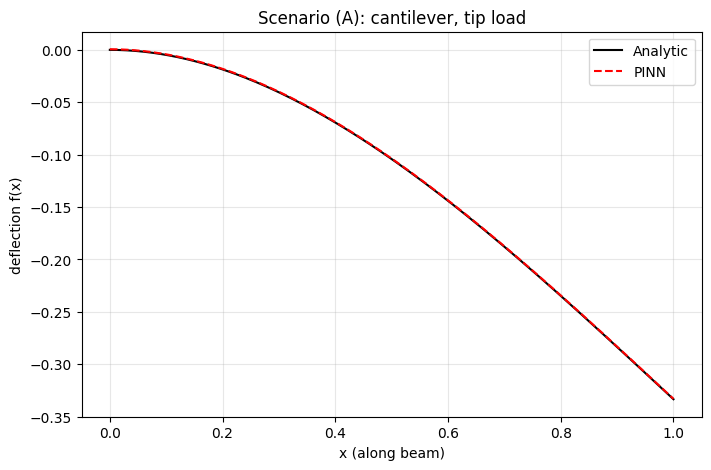

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_A.png
Boundary condition residuals (A):
  disp_0 = [0.00060873]
  slope_0 = [-0.00040215]
  moment_L = [0.00013033]
  shear_L_minus_F = [-0.00049067]


In [20]:
# Scenario (A): PINN vs analytic, save under charts/
plot_pinn_vs_analytic(
    "Scenario (A): cantilever, tip load",
    f_analytic_A,
    "1b_A.png",
    invert_yaxis=False,
)
bc = bc_terms_case_A()
print("Boundary condition residuals (A):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


#### PINN for (B): cantilever, uniform load


In [12]:
# Scenario (B): cantilever, uniform load — f'''' = w (EI=1 → Q_load = W)
Q_load.assign(W)
model = make_model()
train_pinn(bc_terms_case_B)


step: 0   total: 0.8705716729164124   pde: 0.8683598041534424   bc: 0.0022118454799056053
step: 200   total: 0.006609247997403145   pde: 0.005241109058260918   bc: 0.001368139055557549
step: 400   total: 0.0023282268084585667   pde: 0.0022925930097699165   bc: 3.5633882362162694e-05
step: 600   total: 0.0013665984151884913   pde: 0.0013591214083135128   bc: 7.477047802240122e-06
step: 800   total: 0.0009120390168391168   pde: 0.0009084473713301122   bc: 3.5916641536459792e-06
step: 1000   total: 0.0006459286669269204   pde: 0.0006445848848670721   bc: 1.3437979760055896e-06
step: 1200   total: 0.00046287046279758215   pde: 0.00043490753159858286   bc: 2.796291846607346e-05
step: 1400   total: 0.00034760634298436344   pde: 0.00033834128407761455   bc: 9.265068001695909e-06
step: 1600   total: 0.0004375580756459385   pde: 0.0004333826946094632   bc: 4.175374670012388e-06
step: 1800   total: 9.865260653896257e-05   pde: 9.840221900958568e-05   bc: 2.503890641492035e-07
step: 2000   total:

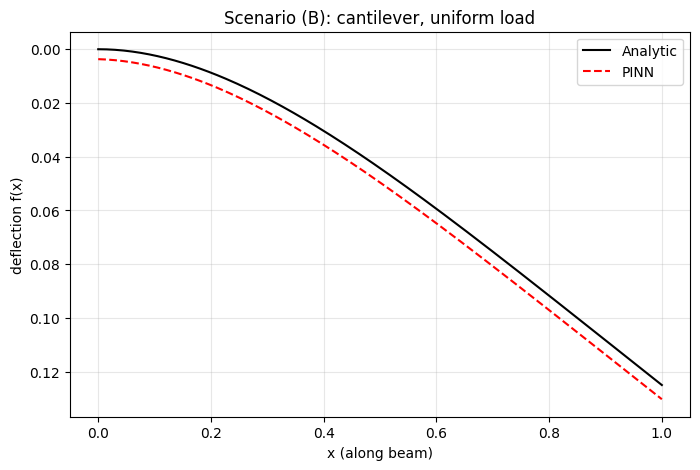

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_B.png
Boundary condition residuals (B):
  disp_0 = [0.00369887]
  slope_0 = [0.00562525]
  moment_L = [0.00089375]
  shear_L = [0.01122304]


In [13]:
plot_pinn_vs_analytic(
    "Scenario (B): cantilever, uniform load",
    f_analytic_B,
    "1b_B.png",
)
bc = bc_terms_case_B()
print("Boundary condition residuals (B):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


#### PINN for (C): simply supported, uniform load


In [14]:
# Scenario (C): simply supported, uniform load w (code: W). Part (a) deflection has y'''' = -w/EI with EI=1.
Q_load.assign(-W)
model = make_model()
train_pinn(bc_terms_case_C)


step: 0   total: 0.5362168550491333   pde: 0.49954918026924133   bc: 0.03666767477989197
step: 200   total: 0.005576461553573608   pde: 0.004331799224019051   bc: 0.0012446624459698796
step: 400   total: 0.0023857499472796917   pde: 0.0018066976917907596   bc: 0.0005790521390736103
step: 600   total: 0.0009206810500472784   pde: 0.0009132484556175768   bc: 7.432612164848251e-06
step: 800   total: 0.0004944269894622266   pde: 0.0004915986792184412   bc: 2.8282975108595565e-06
step: 1000   total: 0.0009219711064361036   pde: 0.000404697610065341   bc: 0.0005172734963707626
step: 1200   total: 6.377368117682636e-05   pde: 6.347959424601868e-05   bc: 2.9408474233605375e-07
step: 1400   total: 4.466884638532065e-05   pde: 4.4505184632726014e-05   bc: 1.636622215528405e-07
step: 1600   total: 8.835124754114076e-05   pde: 8.748434629524127e-05   bc: 8.66898972162744e-07
step: 1800   total: 5.618587601929903e-05   pde: 5.16358959430363e-05   bc: 4.549979166768026e-06
step: 2000   total: 0.0023

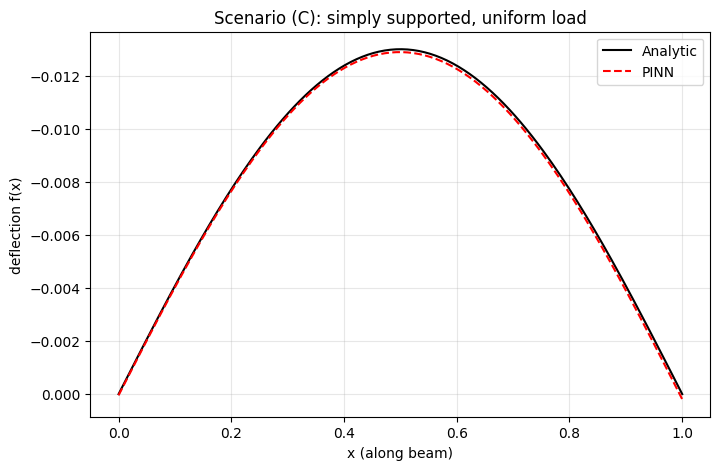

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_C.png
Boundary condition residuals (C):
  disp_0 = [4.2852014e-05]
  disp_L = [0.00019293]
  moment_0 = [8.710986e-05]
  moment_L = [9.267032e-05]


In [15]:
plot_pinn_vs_analytic(
    "Scenario (C): simply supported, uniform load",
    f_analytic_C,
    "1b_C.png",
)
bc = bc_terms_case_C()
print("Boundary condition residuals (C):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))
